<a href="https://colab.research.google.com/github/S-idd/GENAINPTEL/blob/main/WEEK2PE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense ,Input
from tensorflow.keras.models import Model

In [25]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

x_train = x_train.astype('float32')/255

x_test = x_test.astype('float32')/255

x_train = x_train.reshape(len(x_train),784 )
x_test = x_test.reshape(len(x_test),784 )

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [26]:
input_img = Input(shape=(784,))

encoded = Dense (64 ,activation='relu')(input_img)
decoded = Dense (784 ,activation='sigmoid')(encoded)

shallow_ae = Model(input_img,decoded)

shallow_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

shallow_ae.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = shallow_ae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.0111 - loss: 0.2440 - val_accuracy: 0.0124 - val_loss: 0.1631
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0111 - loss: 0.1442 - val_accuracy: 0.0103 - val_loss: 0.1273
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0106 - loss: 0.1191 - val_accuracy: 0.0093 - val_loss: 0.1092
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0104 - loss: 0.1046 - val_accuracy: 0.0101 - val_loss: 0.0982
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.0117 - loss: 0.0953 - val_accuracy: 0.0114 - val_loss: 0.0905


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


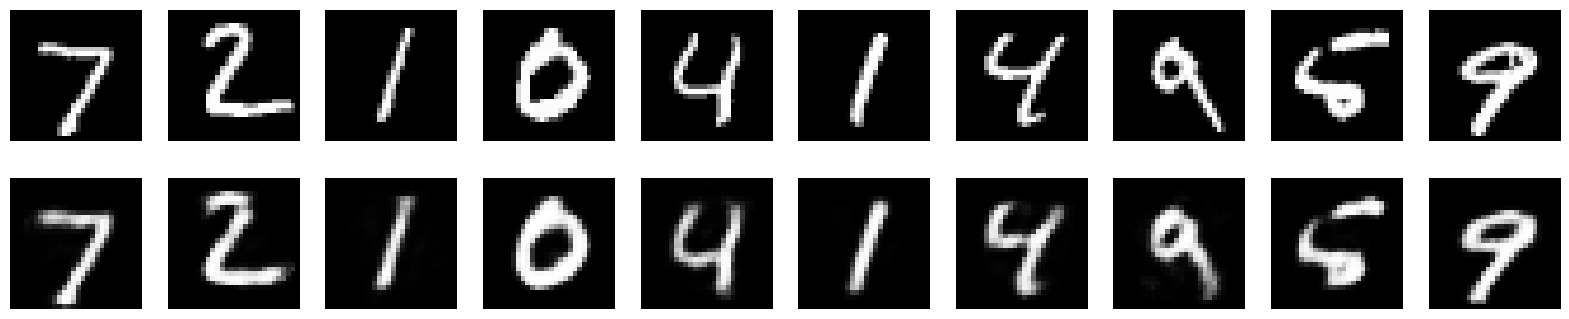

In [28]:
decoded_imgs = shallow_ae.predict(x_test)

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

plt.show()

Deep AutoEncoder

In [29]:
input_img = Input(shape=(784,))

encoded = Dense (256 ,activation='relu')(input_img)
encoded = Dense (128 ,activation='relu')(encoded)
encoded = Dense (64 ,activation='relu')(encoded)


decoded = Dense (128 ,activation='relu')(encoded)
decoded = Dense (256 ,activation='relu')(decoded)
decoded = Dense (784 ,activation='sigmoid')(decoded)

deep_ae = Model(input_img ,decoded );

deep_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deep_ae.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
deep_ae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0106 - loss: 0.2161 - val_accuracy: 0.0143 - val_loss: 0.1391
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0126 - loss: 0.1254 - val_accuracy: 0.0106 - val_loss: 0.1133
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.0113 - loss: 0.1099 - val_accuracy: 0.0115 - val_loss: 0.1044
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0115 - loss: 0.1025 - val_accuracy: 0.0124 - val_loss: 0.0982
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.0121 - loss: 0.0977 - val_accuracy: 0.0140 - val_loss: 0.0947


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


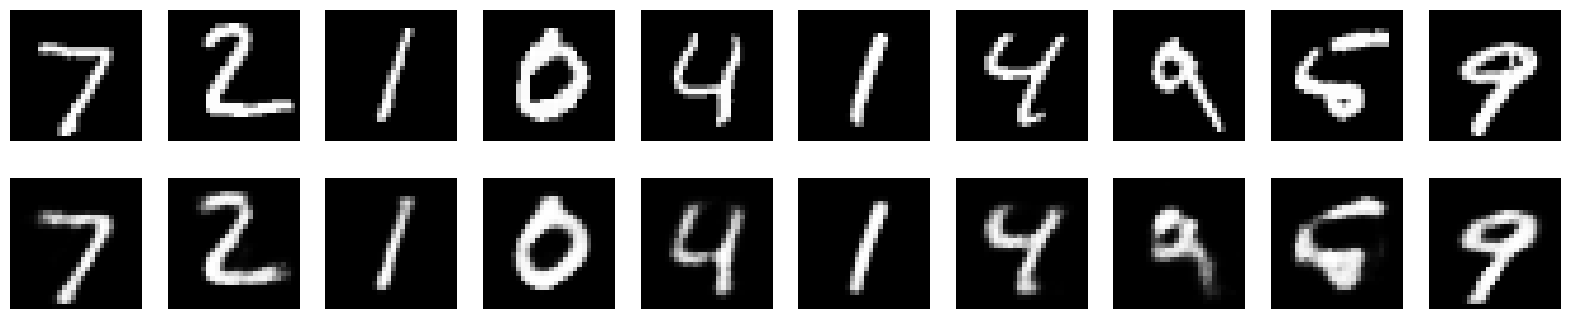

In [31]:
decoded_imgs = deep_ae.predict(x_test)

plt.figure(figsize=(20,4))

for i in range(n):

  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28 ),cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2,n,i+11)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

plt.show()

In [32]:
from tensorflow.keras  import regularizers

input_img = Input(shape=(784,))

encoded = Dense (256 ,activation='relu',activity_regularizer=regularizers.l1(10e-5))(input_img)

decoded = Dense (784 ,activation='sigmoid')(encoded)

sparse_ae = Model(input_img ,decoded );

sparse_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

sparse_ae.summary()



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,448 (1.54 MB)

 Trainable params: 402,448 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
sparse_ae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.0135 - loss: 0.6677 - val_accuracy: 0.0143 - val_loss: 0.6155
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.0149 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5534
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.0149 - loss: 0.5274 - val_accuracy: 0.0161 - val_loss: 0.5037
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4637
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0148 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4313


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


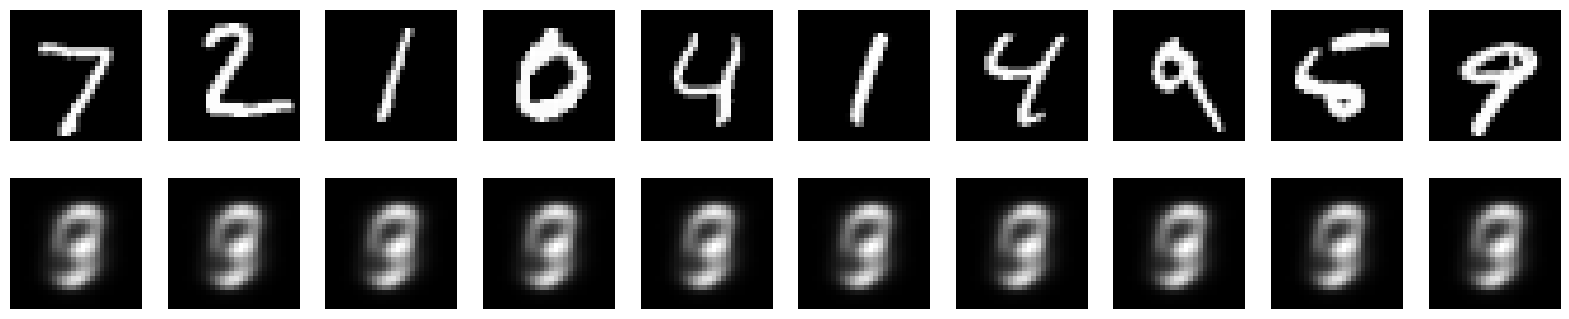

In [34]:
decoded_imgs = sparse_ae.predict(x_test)

plt.figure(figsize=(20,4))

for i in range(n):

  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

plt.show()

In [35]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc = 0.0,
    scale = 1.0,
    size = x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc = 0.0,
    scale = 1.0,
    size = x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.0,1.0)
x_test_noisy = np.clip(x_test_noisy,0.0,1.0)

In [36]:
input_img = Input(shape=(784,))

encoded = Dense (128 ,activation='relu')(input_img)
encoded = Dense (64 ,activation='relu')(encoded)

decoded = Dense (128 ,activation='relu')(encoded)
decoded = Dense (784 ,activation='sigmoid')(decoded)

denoising_ae = Model(input_img ,decoded );

denoising_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

denoising_ae.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
denoising_ae.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.0112 - loss: 0.2474 - val_accuracy: 0.0121 - val_loss: 0.1779
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0127 - loss: 0.1648 - val_accuracy: 0.0116 - val_loss: 0.1528
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0106 - loss: 0.1471 - val_accuracy: 0.0102 - val_loss: 0.1400
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0108 - loss: 0.1380 - val_accuracy: 0.0123 - val_loss: 0.1337
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0117 - loss: 0.1329 - val_accuracy: 0.0119 - val_loss: 0.1297


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


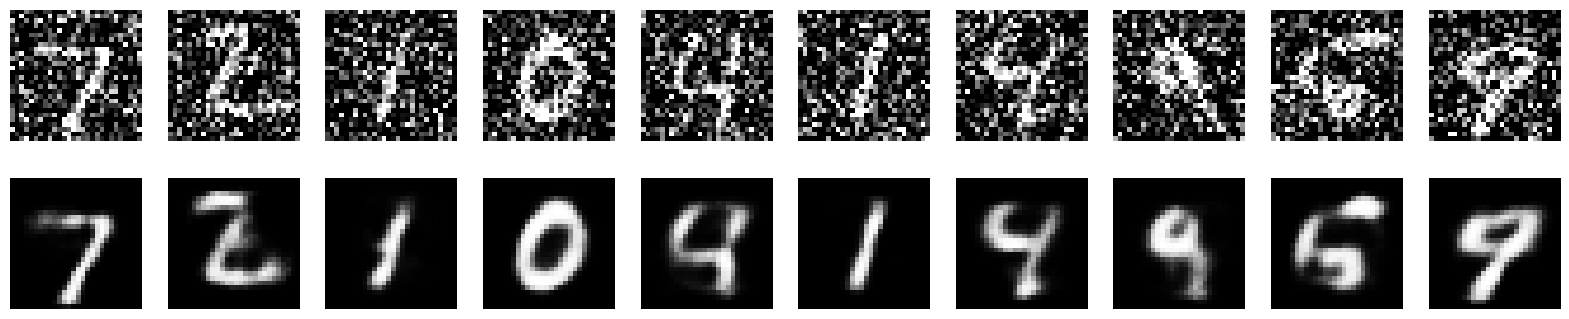

In [38]:
decoded_imgs = denoising_ae.predict(x_test_noisy)

plt.figure(figsize=(20,4))

for i in range(n):

  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap = 'gray')
  plt.axis('off')

plt.show()